Saved: ../data/tangier_synthetic_water_model_with_supply_FIXED_STORAGE_2000_2035.csv
count    432.000000
mean      61.556102
std       15.743637
min       23.867360
25%       50.349065
50%       61.953994
75%       72.402410
max      140.000000
Name: storage_baseline_mcm, dtype: float64
Zero ratio: 0.0


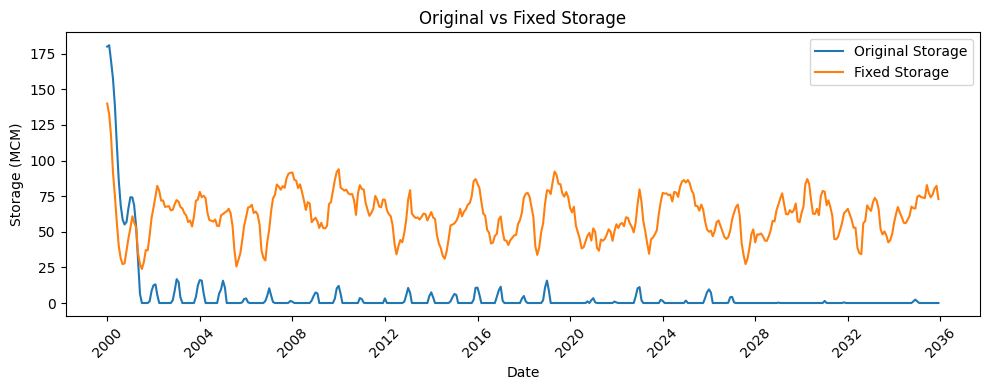

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load original dataset
df = pd.read_csv("../data/tangier_synthetic_water_model_with_supply_2000_2035.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["storage_original_mcm"] = df["storage_baseline_mcm"]

np.random.seed(42)

def build_storage_proxy(df, capacity=175.0, floor=20.0, initial=140.0):
    n = len(df)
    storage = np.zeros(n)
    storage[0] = initial

    # Normalize useful drivers
    rain_norm = (df["rainfall_mm"] - df["rainfall_mm"].min()) / (
        df["rainfall_mm"].max() - df["rainfall_mm"].min()
    )
    supply_norm = (df["supply_mcm"] - df["supply_mcm"].min()) / (
        df["supply_mcm"].max() - df["supply_mcm"].min()
    )
    demand_norm = (df["total_demand_mcm"] - df["total_demand_mcm"].min()) / (
        df["total_demand_mcm"].max() - df["total_demand_mcm"].min()
    )
    temp_norm = (df["temperature_c"] - df["temperature_c"].min()) / (
        df["temperature_c"].max() - df["temperature_c"].min()
    )

    # Slow non-repeating climate management drift
    t = np.arange(n)
    long_drift = 0.08 * np.sin(2 * np.pi * t / (12 * 5) + 0.8) + 0.05 * np.cos(2 * np.pi * t / (12 * 7))

    for i in range(1, n):

        net = (
            18.0 * supply_norm.iloc[i]
            + 10.0 * rain_norm.iloc[i]
            - 14.0 * demand_norm.iloc[i]
            - 6.0 * temp_norm.iloc[i]
        )

    # Persistence (memory effect)
        persistence = 0.85 * storage[i - 1]

    # Weak regulation toward mid level (not too strong!)
        regulation = 0.05 * (120 - storage[i - 1])

    # Random shocks (important)
        shock = np.random.normal(0, 6.0)

    # Occasional drought / surplus events
        if np.random.rand() < 0.05:
            shock -= np.random.uniform(10, 25)  # drought drop

        if np.random.rand() < 0.05:
            shock += np.random.uniform(10, 20)  # wet spike

        storage[i] = persistence + net + regulation + shock

        storage[i] = np.clip(storage[i], floor, capacity)
    # light smoothing only
    storage = pd.Series(storage).ewm(span=2, adjust=False).mean().values
    storage = np.clip(storage, floor, capacity)
    return storage

df["storage_reconstructed_mcm"] = build_storage_proxy(df)
df["storage_baseline_mcm"] = df["storage_reconstructed_mcm"]

output_path = "../data/tangier_synthetic_water_model_with_supply_FIXED_STORAGE_2000_2035.csv"
df.to_csv(output_path, index=False)

print("Saved:", output_path)
print(df["storage_baseline_mcm"].describe())
print("Zero ratio:", (df["storage_baseline_mcm"] == 0).mean())

plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["storage_original_mcm"], label="Original Storage")
plt.plot(df["date"], df["storage_baseline_mcm"], label="Fixed Storage")
plt.title("Original vs Fixed Storage")
plt.xlabel("Date")
plt.ylabel("Storage (MCM)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()